In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv("bearingdata.csv")
df


,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1
...,...,...,...,...,...,...,...,...,...,...
2295,0.21425,-0.19839,0.010769,0.064100,0.064983,-0.212497,-0.119312,3.297037,6.034174,Normal_1
2296,0.21967,-0.20882,0.013136,0.068654,0.069883,-0.061308,-0.295122,3.143410,5.319958,Normal_1
2297,0.20799,-0.21613,0.012571,0.067128,0.068279,-0.154754,-0.071405,3.046161,5.431299,Normal_1
2298,0.21425,-0.22405,0.012608,0.066813,0.067977,-0.326966,0.023662,3.151821,5.391672,Normal_1


In [2]:
# 데이터 타입 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2300 entries, 0 to 2299
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   max       2300 non-null   float64
 1   min       2300 non-null   float64
 2   mean      2300 non-null   float64
 3   sd        2300 non-null   float64
 4   rms       2300 non-null   float64
 5   skewness  2300 non-null   float64
 6   kurtosis  2300 non-null   float64
 7   crest     2300 non-null   float64
 8   form      2300 non-null   float64
 9   fault     2300 non-null   object 
dtypes: float64(9), object(1)
memory usage: 179.8+ KB


In [ ]:
# 데이터 통계치 확인
df.describe()

,max,min,mean,sd,rms,skewness,kurtosis,crest,form
count,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000
mean,1.575079,-1.550994,0.015711,0.341601,0.342289,-0.042251,2.664444,4.173130,26.544769
std,1.578422,1.602706,0.006469,0.305279,0.304813,0.180774,4.411096,1.148349,29.209702
min,0.157300,-6.292600,0.003246,0.059140,0.061067,-1.089928,-0.803795,2.428511,3.484429
25%,0.456398,-2.174975,0.011236,0.135506,0.136374,-0.103426,-0.015164,3.260382,7.413359
50%,0.794510,-0.733700,0.013730,0.188551,0.190662,-0.002466,0.816970,3.921650,13.122811
75%,2.278425,-0.426987,0.018638,0.555589,0.555671,0.061093,3.902286,4.815876,39.911894
max,6.825900,-0.160220,0.038386,1.256577,1.256311,1.059512,30.385326,8.821577,313.742612


In [ ]:
# 결함 유형 분포 확인
df['fault'].value_counts()


fault
Ball_007_1    230
Ball_014_1    230
Ball_021_1    230
IR_007_1      230
IR_014_1      230
IR_021_1      230
OR_007_6_1    230
OR_014_6_1    230
OR_021_6_1    230
Normal_1      230
Name: count, dtype: int64

In [3]:
# 결함 그룹 단순화(4종 분류)-->볼, 내부, 외부
def simplify_fault(label):
    if 'Ball' in label:
        return 'Ball'
    elif 'IR' in label:
        return 'IR'
    elif 'OR' in label:
        return 'OR'
    else:
        return 'Normal'

df['fault_simple'] = df['fault'].apply(simplify_fault)


In [4]:
# fault_simple 인코딩
df_encoded = df.copy()
fault_mapping = {'Normal': 0, 'Ball': 1, 'IR': 2, 'OR': 3}
df_encoded['fault_code'] = df_encoded['fault_simple'].map(fault_mapping)


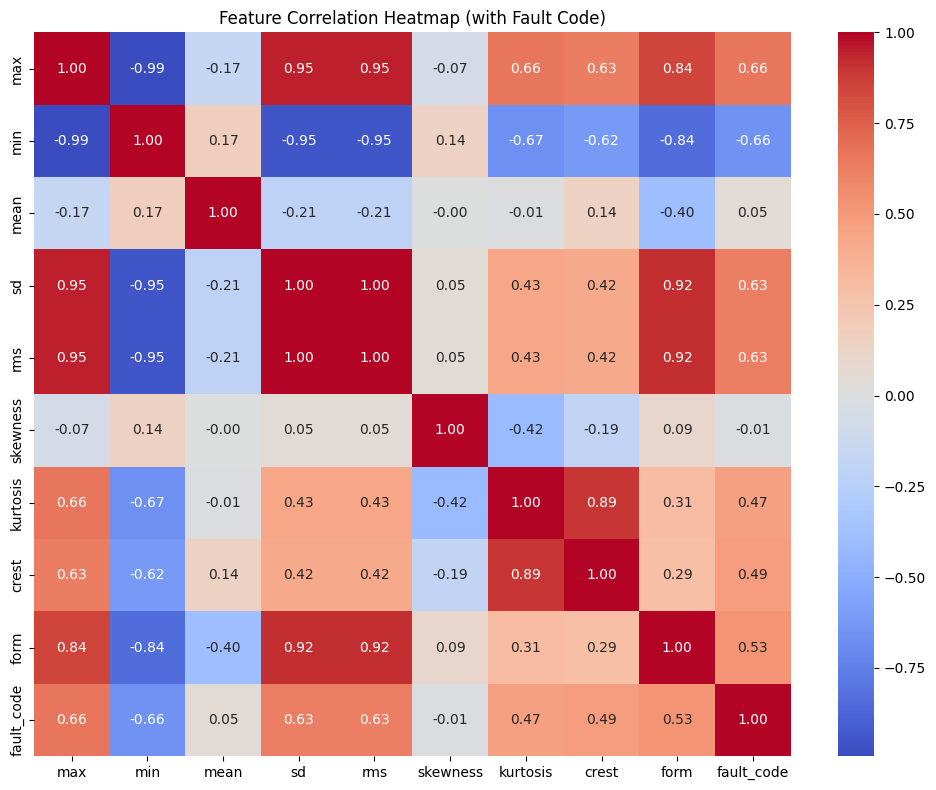

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. fault_simple → 숫자로 인코딩
df_encoded = df.copy()
fault_mapping = {'Normal': 0, 'Ball': 1, 'IR': 2, 'OR': 3}
df_encoded['fault_code'] = df_encoded['fault_simple'].map(fault_mapping)

# 2. 전체 상관관계 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap (with Fault Code)")
plt.tight_layout()
plt.show()

# 결함과 max, sd, rms(진동강도), form(파형의 날카로움)이 양의 상관관계
# rms, sd 상관관계 1, ---> sd 제거? 
# form과 sd, rms 상관관계 1 
# 결함과 mean 상관관계 0에 가까움 -> mean제거


In [21]:
#mean 제거
df = df.drop(columns=['mean'])


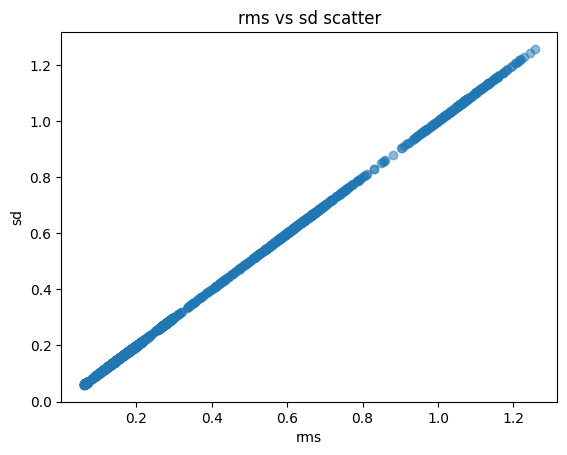

두 변수 간 평균 차이: 0.0007370256218020286
최대 차이: 0.003592537983697991


In [ ]:
# 중복 변수 제거 
import matplotlib.pyplot as plt

# 1) rms vs sd 산점도
plt.scatter(df['rms'], df['sd'], alpha=0.5)
plt.xlabel('rms')
plt.ylabel('sd')
plt.title('rms vs sd scatter')
plt.show()

# 2) 차이값 분석
diff = (df['rms'] - df['sd']).abs()
print("두 변수 간 평균 차이:", diff.mean())
print("최대 차이:", diff.max())

# rms와 sd는 수치적으로 중복-> sd 제거


In [13]:
# sd 제거
df = df.drop(columns=['sd'])  # 원본에서 제거

In [11]:
# 결함 그룹별 평균 비교 
df.groupby('fault_simple').mean(numeric_only=True)


,max,min,mean,sd,rms,skewness,kurtosis,crest,form
fault_simple,,,,,,,,,
Ball,0.595322,-0.556972,0.014115,0.159051,0.159758,0.016483,0.949462,3.700875,12.488163
IR,1.515122,-1.441332,0.021118,0.359442,0.360491,-0.020293,2.086873,4.374890,25.454475
Normal,0.205093,-0.206493,0.012488,0.065046,0.066265,-0.173084,-0.095627,3.093996,5.529295
OR,3.071454,-3.102847,0.012973,0.598497,0.598627,-0.079332,5.877020,4.803336,48.696827


                   max       min      mean       rms  skewness  kurtosis  \
fault_simple                                                               
Ball          0.595322 -0.556972  0.014115  0.159758  0.016483  0.949462   
IR            1.515122 -1.441332  0.021118  0.360491 -0.020293  2.086873   
Normal        0.205093 -0.206493  0.012488  0.066265 -0.173084 -0.095627   
OR            3.071454 -3.102847  0.012973  0.598627 -0.079332  5.877020   

                 crest       form  
fault_simple                       
Ball          3.700875  12.488163  
IR            4.374890  25.454475  
Normal        3.093996   5.529295  
OR            4.803336  48.696827  


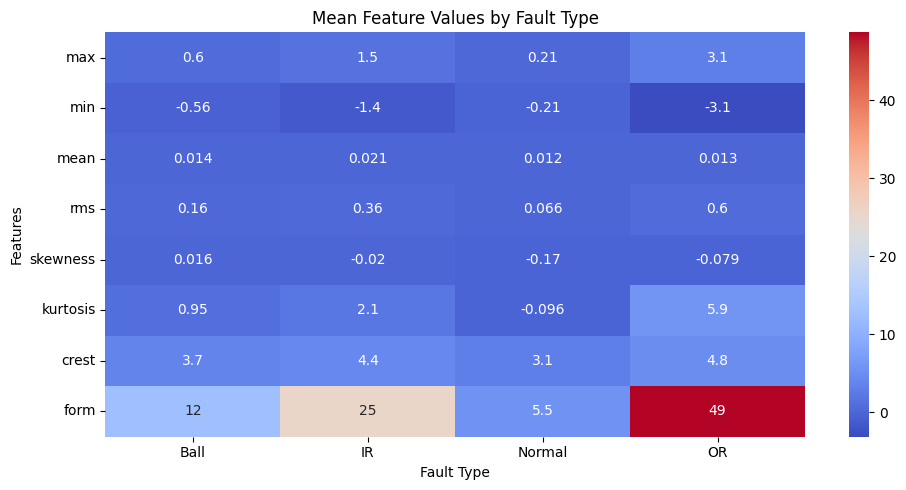

In [ ]:
# 결함별 평균 차이 분석
# 1. 결함 유형별 피처 평균
fault_group_mean = df.groupby('fault_simple').mean(numeric_only=True)
print(fault_group_mean)

# 2. 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(fault_group_mean.T, annot=True, cmap='coolwarm')
plt.title("Mean Feature Values by Fault Type")
plt.ylabel("Features")
plt.xlabel("Fault Type")
plt.tight_layout()
plt.show()

# 외륜 결함은 kurtosis, form, crest에서 압도적으로 큰 값 -> 파형이 매우 충격적이고 불규칙하다는 특징
# Normal은 모든 피처에서 가장 낮은 값
# 히트맵 확인했을 때, form, kurtosis, crest 등이 구분력 높은 주요 피처임을 확인할 수 있었다
# min, skewness 제거할지 하단의 boxplot으로 결정

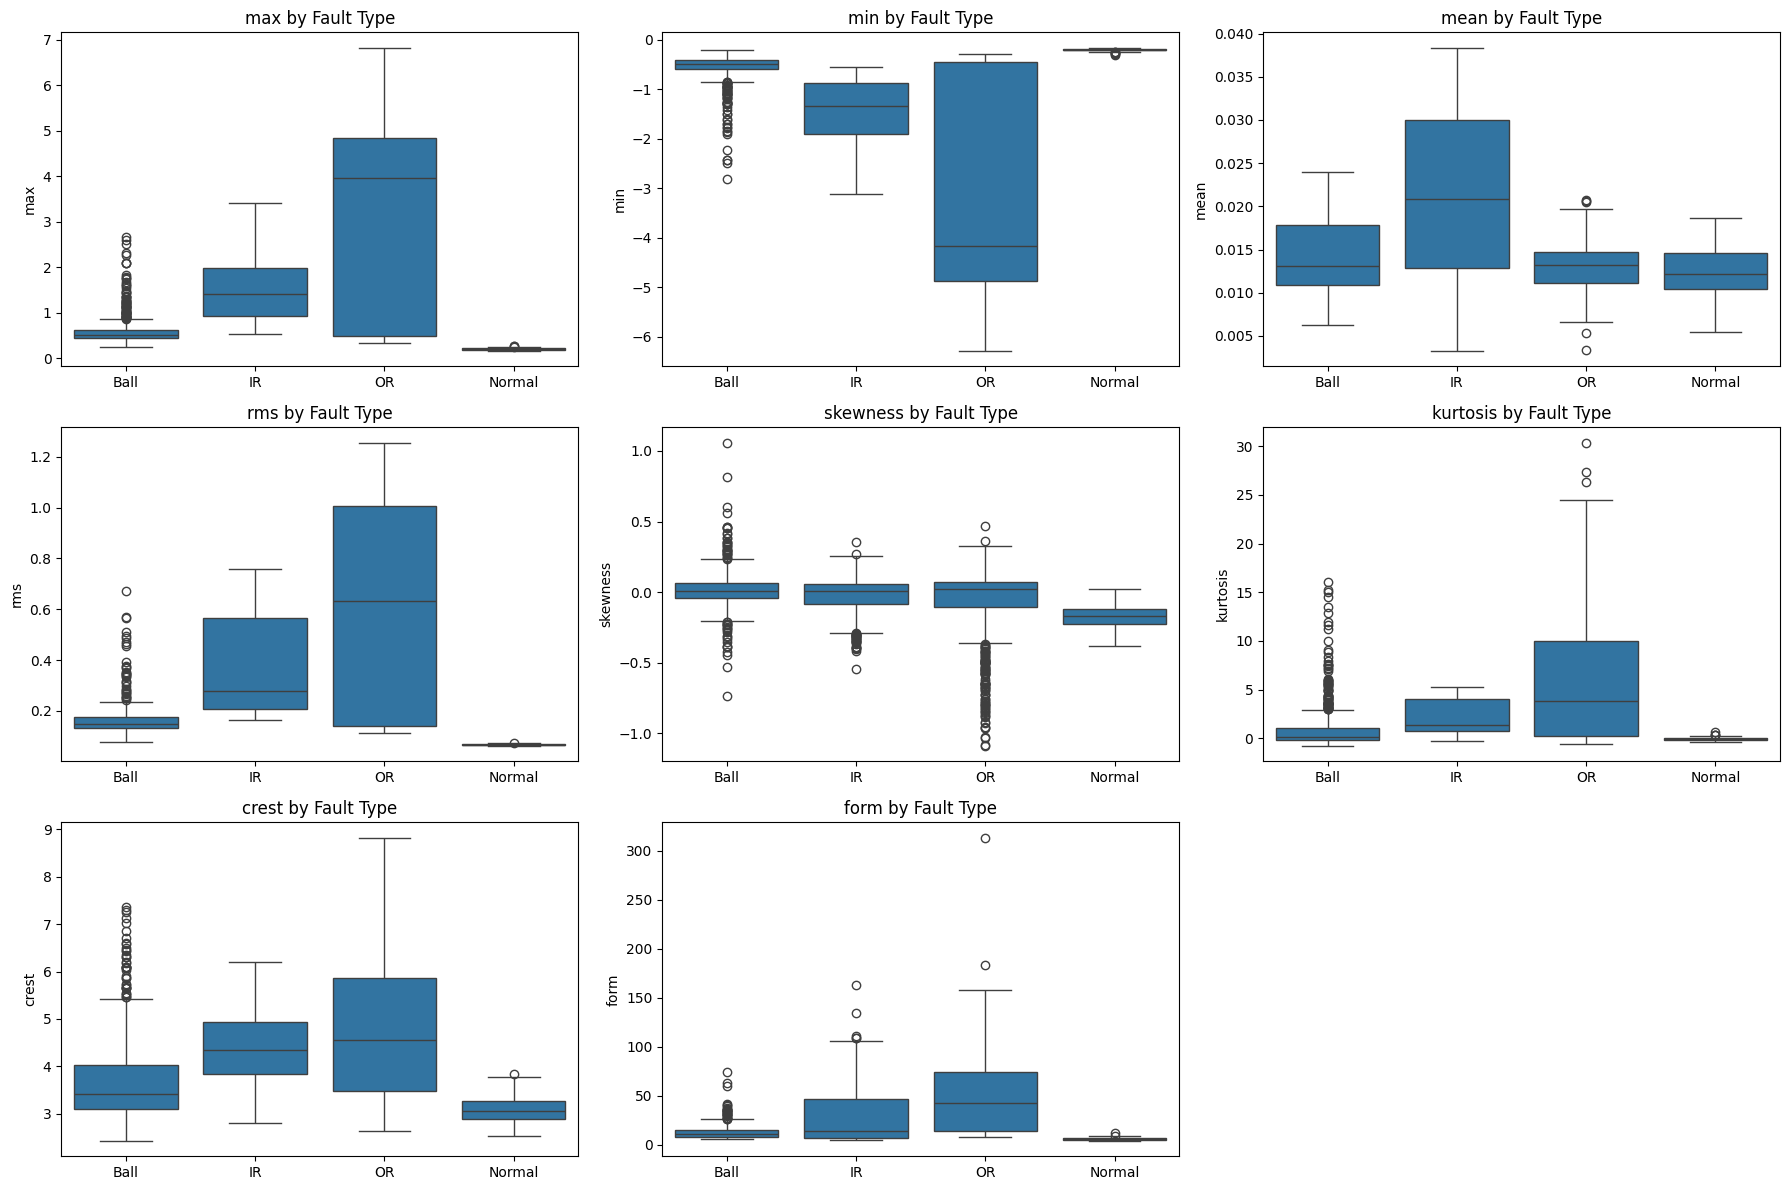

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['max', 'min', 'mean', 'rms', 'skewness', 'kurtosis', 'crest', 'form']
plt.figure(figsize=(18, 12))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='fault_simple', y=col)
    plt.title(f'{col} by Fault Type')
    plt.xlabel('')
    plt.tight_layout()

plt.show()
# min은 외륜 결함에서 음의 진동폭이 뚜렷하게 커지는 경향이 나타나 그대로 유지
# skewness는 boxplot상 유의미한 차이 없음 -->제거


In [ ]:
# skewness 제거
df = df.drop(columns=['skewness'])


In [24]:
df.head()

,max,min,rms,kurtosis,crest,form,fault,fault_simple
0,0.35986,-0.41890,0.124006,-0.042219,2.901946,6.950855,Ball_007_1,Ball
1,0.46772,-0.36111,0.134312,-0.081548,3.482334,6.035202,Ball_007_1,Ball
2,0.46855,-0.43809,0.151008,-0.274069,3.102819,7.376926,Ball_007_1,Ball
3,0.58475,-0.54303,0.158422,0.134692,3.691097,7.558387,Ball_007_1,Ball
4,0.44685,-0.57891,0.139922,0.402783,3.193561,6.312085,Ball_007_1,Ball


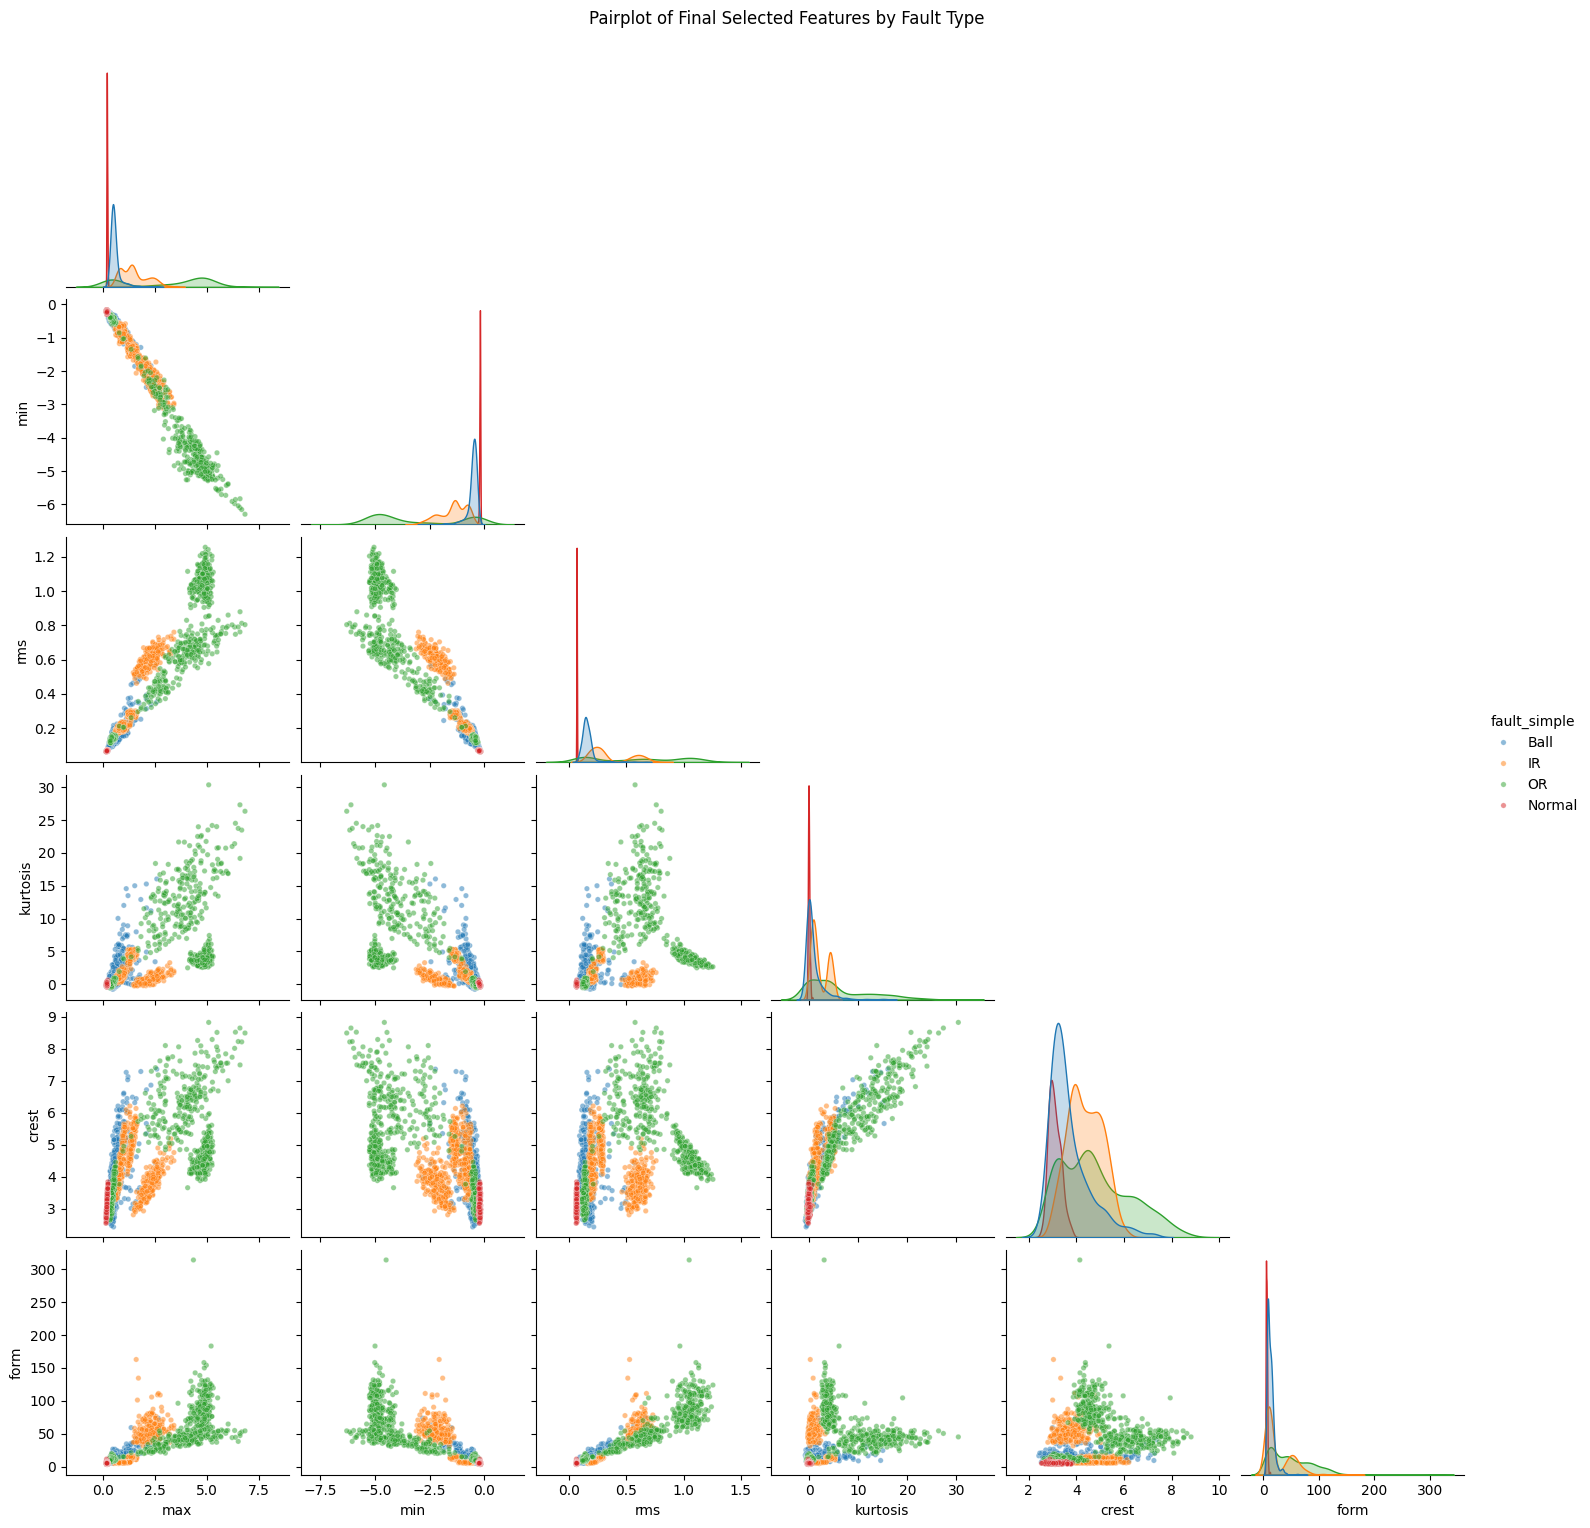

In [ ]:
# pairplot을 통해 주요 피쳐 조합 간 클래스 분포 시각화 
import seaborn as sns
import matplotlib.pyplot as plt

features = ['max', 'min', 'rms', 'kurtosis', 'crest', 'form']

sns.pairplot(df[features + ['fault_simple']], 
             hue='fault_simple', 
             corner=True,
             plot_kws={'alpha': 0.5, 's': 15})

plt.suptitle("Pairplot of Final Selected Features by Fault Type", y=1.02)
plt.show()
# (form, crest) : 외륜결함과 정상이 잘 분리됨

| 피처 조합 (행, 열)           | 구분도     | 해석 요약                        |
| ---------------------- | ------- | ---------------------------- |
| (form, crest) (6,5)    |  매우 높음 | OR은 우상단, Normal은 좌하단 → 완벽 분리 |
| (form, rms) (6,3)      |  높음    | 대각선 방향으로 OR vs Normal 분리     |
| (form, kurtosis) (6,4) |  높음    | OR만 `kurtosis`가 매우 큼         |
| (max, min) (1,2)       |  높음    | OR은 양끝치우침, Normal은 중앙 집중     |


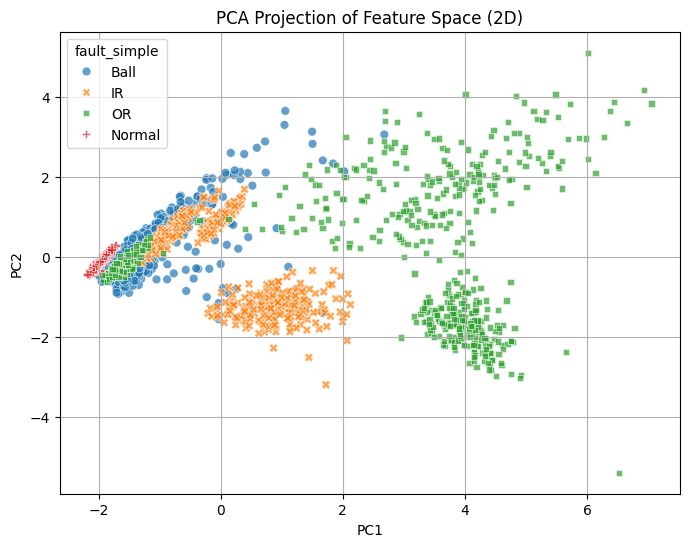

In [ ]:
#PCA(정규화 이전)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 피처와 라벨 선택
features = ['max', 'min', 'rms', 'kurtosis', 'crest', 'form']
X = df[features]
y = df['fault_simple']

# 2. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA 적용
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. 결과 데이터프레임 생성
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['fault_simple'] = y

# 5. 시각화
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='fault_simple', style='fault_simple', s=40, alpha=0.7)
plt.title("PCA Projection of Feature Space (2D)")
plt.grid(True)
plt.show()

In [ ]:
# PCA 결과 보기(정규화 이전)
import pandas as pd

components = pd.DataFrame(pca.components_, columns=features, index=['PC1', 'PC2'])
print(components)


          max       min       rms  kurtosis     crest      form
PC1  0.464014 -0.462829  0.432275  0.346035  0.333890  0.390379
PC2 -0.086341  0.086824 -0.329589  0.573115  0.592244 -0.444031


### PCA 결과

| PC축     | 설명         | 주요 변수                       | 실제 분리 기준              |
| ------- | ---------- | --------------------------- | --------------------- |
| **PC1** | 진폭 기반 주축   | `max`, `min`, `rms`, `form` |  OR vs Normal 구분 핵심  |
| **PC2** | 충격성/스파이크 축 | `crest`, `kurtosis`, `form` |  Ball vs IR 약간 구분 가능 |


In [33]:
df.head()

,max,min,rms,kurtosis,crest,form,fault,fault_simple
0,0.35986,-0.41890,0.124006,-0.042219,2.901946,6.950855,Ball_007_1,Ball
1,0.46772,-0.36111,0.134312,-0.081548,3.482334,6.035202,Ball_007_1,Ball
2,0.46855,-0.43809,0.151008,-0.274069,3.102819,7.376926,Ball_007_1,Ball
3,0.58475,-0.54303,0.158422,0.134692,3.691097,7.558387,Ball_007_1,Ball
4,0.44685,-0.57891,0.139922,0.402783,3.193561,6.312085,Ball_007_1,Ball


In [34]:
# StandardScaler 적용
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 정규화 대상 데이터: 숫자형 feature만
X = df.drop(columns=['fault', 'fault_simple'])  # 문자열 제거
y = df['fault_simple']  # 예측용 타겟은 따로 저장

# StandardScaler 적용
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

# 다시 DataFrame으로 변환
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

# 결과 확인
print(X_scaled.describe())
print(X_scaled.head())


                max           min           rms      kurtosis         crest  \
count  2.300000e+03  2.300000e+03  2.300000e+03  2.300000e+03  2.300000e+03   
mean   4.942906e-17 -9.885812e-17 -9.885812e-17 -9.885812e-17  5.498983e-16   
std    1.000217e+00  1.000217e+00  1.000217e+00  1.000217e+00  1.000217e+00   
min   -8.984206e-01 -2.959143e+00 -9.228088e-01 -7.864242e-01 -1.519571e+00   
25%   -7.088879e-01 -3.894141e-01 -6.756951e-01 -6.076020e-01 -7.950077e-01   
50%   -4.946322e-01  5.100575e-01 -4.975524e-01 -4.189153e-01 -2.190401e-01   
75%    4.456978e-01  7.014707e-01  7.001954e-01  2.806811e-01  5.598351e-01   
max    3.327350e+00  8.679551e-01  2.999288e+00  6.285720e+00  4.048818e+00   

               form  
count  2.300000e+03  
mean  -4.942906e-17  
std    1.000217e+00  
min   -7.896470e-01  
25%   -6.551101e-01  
50%   -4.596033e-01  
75%    4.577257e-01  
max    9.834414e+00  
        max       min       rms  kurtosis     crest      form
0 -0.770062  0.706518 -0.716

PC1 설명력: 0.7561
PC2 설명력: 0.2055
PC1+PC2 누적 설명력: 0.9617


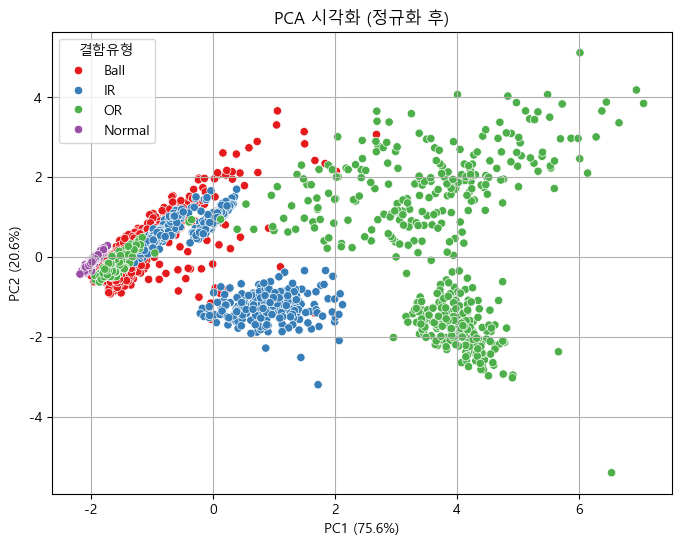

In [36]:
# PCA(정규화 후)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.font_manager as fm

# 한글 폰트 설정 (맑은 고딕 등 사용 가능)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# X_scaled는 정규화된 데이터, y는 fault_simple
# 정규화는 이전에 완료되었으므로 X_scaled 바로 사용

# PCA 적용
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 결과 DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['결함유형'] = y.values  # y는 fault_simple (정상/볼/내륜/외륜)

# 기여율 출력
explained_var = pca.explained_variance_ratio_
print(f"PC1 설명력: {explained_var[0]:.4f}")
print(f"PC2 설명력: {explained_var[1]:.4f}")
print(f"PC1+PC2 누적 설명력: {explained_var[0] + explained_var[1]:.4f}")

# 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='결함유형', palette='Set1')
plt.title('PCA 시각화 (정규화 후)')
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
plt.grid(True)
plt.legend(title='결함유형')
plt.show()



In [37]:
# 변수 이름 리스트
features = ['max', 'min', 'rms', 'kurtosis', 'crest', 'form']

# 주성분 별 구성 계수 출력
components = pd.DataFrame(pca.components_, columns=features, index=['PC1', 'PC2'])
print("PCA 주성분 구성:")
print(components)


PCA 주성분 구성:
          max       min       rms  kurtosis     crest      form
PC1  0.464014 -0.462829  0.432275  0.346035  0.333890  0.390379
PC2 -0.086341  0.086824 -0.329589  0.573115  0.592244 -0.444031


| 주성분     | 기여율       | 주요 기여 변수                    | 의미       | 어떤 클래스 구분에 유리? |
| ------- | --------- | --------------------------- | -------- | -------------- |
| **PC1** | **75.6%** | `max`, `min`, `rms`, `form` | 진폭 + 형태  | OR vs Normal   |
| **PC2** | **20.6%** | `crest`, `kurtosis`, `form` | 충격/스파이크성 | Ball vs IR     |


## 기본 모델 학습

In [40]:
from sklearn.preprocessing import LabelEncoder

# y 값 숫자형으로 변환
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'SVM': SVC(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42)
}


In [42]:
#학습 및 평가
from sklearn.metrics import classification_report

for name, model in models.items():
    if name in ['XGBoost', 'LightGBM']:
        model.fit(X_train, y_train_enc)  # 숫자 라벨
        y_pred_enc = model.predict(X_test)
        y_pred = le.inverse_transform(y_pred_enc)  # 다시 문자로
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    print(f"\n {name} 결과:")
    print(classification_report(y_test, y_pred))



 RandomForest 결과:
              precision    recall  f1-score   support

        Ball       0.95      0.90      0.93       138
          IR       0.97      1.00      0.99       138
      Normal       1.00      1.00      1.00        46
          OR       0.93      0.96      0.94       138

    accuracy                           0.96       460
   macro avg       0.96      0.96      0.96       460
weighted avg       0.96      0.96      0.96       460


 LogisticRegression 결과:
              precision    recall  f1-score   support

        Ball       0.74      0.91      0.82       138
          IR       0.91      0.97      0.94       138
      Normal       0.98      1.00      0.99        46
          OR       0.98      0.67      0.79       138

    accuracy                           0.87       460
   macro avg       0.90      0.89      0.88       460
weighted avg       0.88      0.87      0.86       460


 SVM 결과:
              precision    recall  f1-score   support

        Ball       0.

c:\AIDC\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [11:10:54] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



 XGBoost 결과:
              precision    recall  f1-score   support

        Ball       0.95      0.91      0.93       138
          IR       0.98      1.00      0.99       138
      Normal       1.00      1.00      1.00        46
          OR       0.92      0.94      0.93       138

    accuracy                           0.95       460
   macro avg       0.96      0.96      0.96       460
weighted avg       0.95      0.95      0.95       460

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000236 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 1840, number of used features: 6
[LightGBM] [Info] Start training from score -1.203973
[LightGBM] [Info] Start training from score -1.203973
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -1.203973
[LightGBM] [Warning] No further splits with posi

In [44]:
# 출력 생략 없이 모두 보이게 설정
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [46]:
from sklearn.metrics import classification_report

# LightGBM 모델 학습 및 예측
model = LGBMClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 결과 출력
print("LightGBM 결과:")
print(classification_report(y_test, y_pred, target_names=le.classes_))  # le = LabelEncoder


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 1840, number of used features: 6
[LightGBM] [Info] Start training from score -1.203973
[LightGBM] [Info] Start training from score -1.203973
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -1.203973
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

LGBMClassifier()

LightGBM 결과:
              precision    recall  f1-score   support

        Ball       0.98      0.91      0.94       138
          IR       0.99      1.00      0.99       138
      Normal       1.00      1.00      1.00        46
          OR       0.93      0.98      0.95       138

    accuracy                           0.97       460
   macro avg       0.97      0.97      0.97       460
weighted avg       0.97      0.97      0.97       460

